In [1]:
import torch
import torch.nn as nn
from torchvision import models
import matplotlib.pyplot as plt
import numpy as np

from Dataloader import get_dataloaders, CLASS_NAMES

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
MODEL_PATH = "checkpoints/best_model_v6.pth"
DATA_DIR = "dataset"

print(f"A usar dispositivo: {DEVICE}")

c:\Users\diogo\anaconda3\envs\APmod2\lib\site-packages\requests\__init__.py:86: RequestsDependencyWarning: Unable to find acceptable character detection dependency (chardet or charset_normalizer).
  warnings.warn(


A usar dispositivo: cpu


In [2]:
def build_model(num_classes=4, dropout=0.3):
    model = models.convnext_small(weights=None)
    in_features = 768
    model.classifier[2] = nn.Sequential(
        nn.Dropout(p=dropout, inplace=True),
        nn.Linear(in_features, num_classes),
    )
    return model

_, _, test_loader, _, _ = get_dataloaders(data_dir=DATA_DIR, batch_size=1)
print("Dataloader atual carregado com sucesso.")

model = build_model(num_classes=4).to(DEVICE)
ckpt = torch.load(MODEL_PATH, map_location=DEVICE, weights_only=False)
model.load_state_dict(ckpt["model_state"])
model.eval()
print(f"Modelo V6 carregado (Época do checkpoint: {ckpt.get('epoch', 'N/A')})")

test_iter = iter(test_loader)

train: 1067 | val: 234 | test: 267

 WeightedRandomSampler:
   Biliary_Leaks        →  110 imgs | peso = 2.4250
   Lithiasis            →  505 imgs | peso = 0.5282
   Normal               →  197 imgs | peso = 1.3541
   Stricture            →  255 imgs | peso = 1.0461

Class weights: [2.424999952316284, 0.5282177925109863, 1.3540608882904053, 1.0460784435272217]
Dataloader atual carregado com sucesso.
Modelo V6 carregado (Época do checkpoint: 19)


c:\Users\diogo\anaconda3\envs\APmod2\lib\site-packages\torch\utils\data\dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


In [3]:
class ConvNeXtGradCAM:
    def __init__(self, model):
        self.model = model
        self.gradients = None
        self.activations = None
        
        target_layer = self.model.features[-1][-1]
        
        target_layer.register_forward_hook(self.save_activation)
        target_layer.register_full_backward_hook(self.save_gradient)

    def save_activation(self, module, input, output):
        self.activations = output

    def save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0]

    def generate_cam(self, input_tensor, target_class):
        self.model.zero_grad()
        output = self.model(input_tensor)
        
        if target_class is None:
            target_class = output.argmax(dim=1).item()
            
        output[0, target_class].backward()
        
        weights = torch.mean(self.gradients, dim=[2, 3], keepdim=True)
        
        cam = torch.sum(weights * self.activations, dim=1).squeeze()
        
        cam = torch.relu(cam)
        cam = cam.cpu().detach().numpy()
        
        cam = cam - np.min(cam)
        cam = cam / (np.max(cam) + 1e-8)
        return cam, output.argmax(dim=1).item()

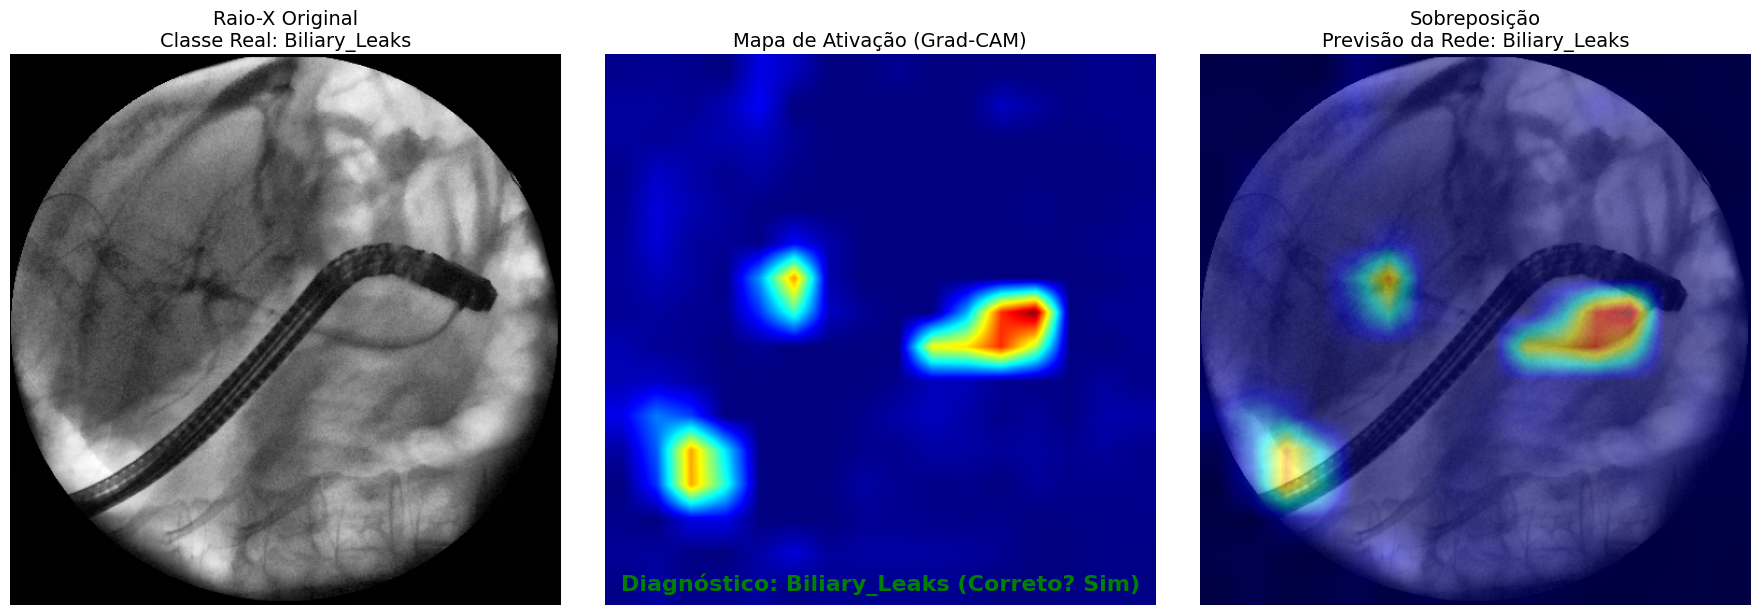

In [ ]:
import cv2

cam_extractor = ConvNeXtGradCAM(model)

try:
    batch = next(test_iter)
except StopIteration:
    print("Fim do dataset de teste atingido. A reiniciar o ciclo a partir da primeira imagem...")
    test_iter = iter(test_loader)
    batch = next(test_iter)

img_tensor = batch["image"].to(DEVICE)
label_idx = batch["label"][0].item()
true_class = CLASS_NAMES[label_idx]

cam, pred_idx = cam_extractor.generate_cam(img_tensor, target_class=None)
pred_class = CLASS_NAMES[pred_idx]

img_vis = img_tensor[0].cpu().numpy().transpose(1, 2, 0)
img_vis = (img_vis - img_vis.min()) / (img_vis.max() - img_vis.min() + 1e-8)

cam_resized = cv2.resize(cam, (img_vis.shape[1], img_vis.shape[0]))
heatmap = cv2.applyColorMap(np.uint8(255 * cam_resized), cv2.COLORMAP_JET)
heatmap = cv2.cvtColor(heatmap, cv2.COLOR_BGR2RGB) / 255.0

overlay = 0.5 * img_vis + 0.5 * heatmap

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

axes[0].imshow(img_vis)
axes[0].set_title(f"Raio-X Original\nClasse Real: {true_class}", fontsize=14)
axes[0].axis("off")

axes[1].imshow(heatmap)
axes[1].set_title("Mapa de Ativação (Grad-CAM)", fontsize=14)
axes[1].axis("off")

axes[2].imshow(overlay)
axes[2].set_title(f"Sobreposição\nPrevisão da Rede: {pred_class}", fontsize=14)
axes[2].axis("off")

color = "green" if true_class == pred_class else "red"
plt.figtext(0.5, 0.05, f"Diagnóstico: {pred_class} (Correto? {'Sim' if true_class == pred_class else 'Não'})", 
            ha="center", fontsize=16, color=color, weight="bold")

plt.tight_layout()
plt.show()